## To do
- Figure out why the model is overfitting so quickly
- Try to improve model performance even more (look at elmo embeddings) (save this version then make changes)
- Perform hyperparameter tuning
- Figure out feature importance for the stylometric features (this has efficiency benefits)
- Clean up messy code
- Add installations for non-standard library packages
- Add documentation (including markdown and comments) to explain how this model works

# Installation Scripts

In [6]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 49.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Imports

In [7]:
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
from spacy.symbols import ORTH, POS
from collections import defaultdict, Counter
import math
from nltk import ngrams
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random
import time
import gc

# Constants

In [85]:
KAGGLE_INPUT_PREFIX = "/kaggle/input/datasets/abdullahsweesi/av-data"
TRIAL_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/AV_trial.csv"
TRAIN_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/train.csv"
VAL_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/dev.csv"
TEST_DATA_PATH = f"{KAGGLE_INPUT_PREFIX}/test.csv"
FASTTEXT_PATH = "/kaggle/input/datasets/yekenot/fasttext-crawl-300d-2m/crawl-300d-2M.vec"

BEST_MODEL_PATH = "/kaggle/working/best_model.pt"
GRAPH_OUTPUT_PATH = lambda i: f"/kaggle/working/loss_graph_{i}.png"

nlp = spacy.load("en_core_web_md", disable=["ner"])

MAX_LEN = 256
BATCH_SIZE = 64            # For two GPUs (32 each)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Loading

In [9]:
trial_df = pd.read_csv(TRIAL_DATA_PATH, encoding="utf-8")
train_df = pd.read_csv(TRAIN_DATA_PATH, encoding="utf-8")
val_df = pd.read_csv(VAL_DATA_PATH, encoding="utf-8")
test_df = pd.read_csv(TEST_DATA_PATH, encoding="utf-8")

# Stylometric feature extraction

In [10]:
# makes sure that these are lowercase
TOP_FUNCTION_WORDS = set(word.lower() for word in [
    "the", "of", "and", "to", "a", "in", 
    "is", "you", "that", "was", "he", "his", 
    "for", "it", "with", "as", "on", "are",
    "be", "at", "by", "they", "this", "from", 
    "i", "have", "or", "had", "not", "she"
])
SORTED_TOP_FUNCTION_WORDS = sorted(list(TOP_FUNCTION_WORDS))

FUNCTION_TAGS = {"ADP", "AUX", "CONJ", "CCONJ", "DET", "PART", "PRON", "SCONJ"}
CONTENT_TAGS = {"ADJ", "ADV", "INTJ", "NOUN", "NUM", "PROPN", "VERB"}

NON_WORD_TAGS = {"NUM", "PUNCT", "SYM", "X"}

ALL_NN_FORMS = {"NN", "NNS", "NNP", "NNPS"}                # all noun forms
ALL_JJ_FORMS = {"JJ", "JJR", "JJS"}                        # all adjective forms
ALL_RB_FORMS = {"RB", "RBR", "RBS"}                        # all adverb forms
ALL_VB_FORMS = {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ"}   # all verb forms

def get_top_pos_trigrams():
    trigrams = set()

    for nn in ALL_NN_FORMS:
        trigrams.add((nn, "IN", "DT"))
        trigrams.add(("IN", "DT", nn))
        trigrams.add(("DT", nn, "IN"))
        trigrams.add(("DT", nn, "PUNCT"))
        for nn2 in ALL_NN_FORMS:
            trigrams.add(("DT", nn, nn2))

    for jj in ALL_JJ_FORMS:
        trigrams.add(("IN", "DT", jj))
        for nn in ALL_NN_FORMS:
            trigrams.add(("DT", jj, nn))
            trigrams.add((jj, nn, "IN"))
            trigrams.add((jj, nn, "PUNCT"))
            for rb in ALL_RB_FORMS:
                trigrams.add((rb, jj, nn))

    for vb in ALL_VB_FORMS:
        trigrams.add(("PRP", vb, "DT"))
        trigrams.add(("PRP", vb, "IN"))

    return trigrams
                
TOP_POS_TRIGRAMS = get_top_pos_trigrams()
SORTED_TOP_POS_TRIGRAMS = sorted(list(TOP_POS_TRIGRAMS))
# print(len(TOP_POS_TRIGRAMS))


def extract_stylometric_features(document):
    """
    Processes a spaCy document and returns a []-dimensional feature vector
    """
    f_count, c_count = 0, 0                          # counts of function and content words
    top_function_word_freqs = defaultdict(int)       # frequencies of top function words
    lexical_count = 0                                # count of all words
    unique_words = set()                             # set of all words (no duplicates)
    conjunction_count = 0                            # count of all conjunction words
    long_word_count = 0                              # long word (>6 chars) count
    oov_count, non_oov_count = 0, 0                  # counts of oov and vocabulary words
    word_length_sum = 0                              # sum of all word lengths
    pronoun_freqs = {                                # frequencies of various pronoun types
        "1S": 0,                             # first-person singular
        "1P": 0,                             # first-person plural
        "12": 0,                             # first- and second-person
        "3": 0                               # third-person
    }
    special_punct_freqs = defaultdict(int)           # frequencies of each of ";,.-?!"
    total_punct_count = 0                            # total punctuation count
    top_pos_trigram_freqs = defaultdict(int)         # frequencies of the top POS trigrams
    total_pos_trigram_count = 0                      # total POS trigram count

    # loop over all tokens
    for token in document:
        if token.is_space:
            continue

        text_lower = token.text.lower()
        universal_pos = token.pos_

        # word statistics
        if universal_pos not in NON_WORD_TAGS:
            unique_words.add(text_lower)
            lexical_count += 1
            word_length_sum += len(token.text)

            if text_lower in TOP_FUNCTION_WORDS:
                top_function_word_freqs[text_lower] += 1

            if universal_pos in FUNCTION_TAGS:
                f_count += 1
            elif universal_pos in CONTENT_TAGS:
                c_count += 1

            if universal_pos in ["CONJ", "CCONJ"]:
                conjunction_count += 1
            
            if len(token.text) > 6:
                long_word_count += 1

            if token.is_oov:
                oov_count += 1
            else:
                non_oov_count += 1

        # punctuation statistics
        if universal_pos == "PUNCT":
            total_punct_count += 1
            if token.text in ";,.-?!":
                special_punct_freqs[token.text] += 1

        # personal pronoun statistics
        if universal_pos == "PRON" and "Prs" in token.morph.get("PronType"):
            person = token.morph.get("Person")
            num = token.morph.get("Number")
            if "1" in person:
                pronoun_freqs["12"] += 1
                if "Sing" in num:
                    pronoun_freqs["1S"] += 1
                else:
                    pronoun_freqs["1P"] += 1
            elif "2" in person:
                pronoun_freqs["12"] += 1
            elif "3" in person:
                pronoun_freqs["3"] += 1

    # extract Penn Treebank POS tags
    ptb_tags = [token.tag_ for token in document]

    # loop over all POS trigrams
    for tri in ngrams(ptb_tags, 3):
        total_pos_trigram_count += 1
        if tri in TOP_POS_TRIGRAMS:
            top_pos_trigram_freqs[tri] += 1

    # sentence statistics
    sentence_lengths = [len([t for t in s if not t.is_space]) for s in document.sents]
    mean_sentence_length = np.mean(sentence_lengths) if sentence_lengths else 0
    if len(sentence_lengths) > 1:
        variance = sum((length - mean_sentence_length)**2 for length in sentence_lengths) / len(sentence_lengths)
        std_sentence_length = math.sqrt(variance)
    else:
        std_sentence_length = 0

    # final feature assembly
    feature_vector = []

    # the (normalised) frequencies of each of the top 30 function words [30 features]
    for word in SORTED_TOP_FUNCTION_WORDS:
        feature_vector.append(top_function_word_freqs[word] / (f_count + 1e-9))

    # the (normalised) ratio of function words to content words [1 feature]
    feature_vector.append(np.clip(f_count / (c_count + 1e-9), 0, 5))

    # the (normalised) type-token ratio (i.e proportion of non-unique words) [1 feature]
    feature_vector.append(len(unique_words) / (lexical_count + 1e-9))

    # the (normalised) count of conjunctions (e.g. and, but) [1 feature]
    feature_vector.append(conjunction_count / (f_count + 1e-9))

    # the (normalised) count of long words (>6 chars) [1 feature]
    feature_vector.append(long_word_count / (lexical_count + 1e-9))

    # the (normalised) ratio of OOV words to non-OOV words [1 feature]
    feature_vector.append(np.clip(oov_count / (non_oov_count + 1e-9), 0, 5))

    # the (normalised) ratio of first- and second-person pronouns to third-person pronouns [1 feature]
    feature_vector.append(np.clip(pronoun_freqs["12"] / (pronoun_freqs["3"] + 1e-9), 0, 5))

    # the (normalised) ratio of first-person singular pronouns to first-person plural pronouns [1 feature]
    feature_vector.append(np.clip(pronoun_freqs["1S"] / (pronoun_freqs["1P"] + 1e-9), 0, 5))

    # the mean word length [1 feature]
    feature_vector.append(np.clip(word_length_sum / (lexical_count + 1e-9), 0, 20))

    # the mean sentence length [1 feature]
    feature_vector.append(np.clip(mean_sentence_length, 0, 100))

    # the sentence length standard deviation [1 feature]
    feature_vector.append(np.clip(std_sentence_length, 0, 100))

    # the (normalised) frequencies of punctuation symbols in ';,.-?!' [6 features]
    for symbol in ";,.-?!":
        feature_vector.append(special_punct_freqs[symbol] / (total_punct_count + 1e-9))

    # the (normalised) ratios of punctuation symbol pairs of interest [6 features]
    punctuation_pairs = [
        (",", ";"), (",", "-"),
        (";", "-"), ("?", "."),
        (",", "."), ("!", ".")
    ]
    for s1, s2 in punctuation_pairs:
        feature_vector.append(np.clip(special_punct_freqs[s1] / (special_punct_freqs[s2] + 1e-9), 0, 5))

    # the (normalised) counts of the top POS trigrams [119 features]
    for tri in SORTED_TOP_POS_TRIGRAMS:
        feature_vector.append(top_pos_trigram_freqs[tri] / (total_pos_trigram_count + 1e-9))

    return np.array(feature_vector)

def process_input_stylometry(df):
    feature_vectors_1 = []
    feature_vectors_2 = []

    for document in nlp.pipe(df["text_1"], batch_size=256, n_process=-1, disable=["ner", "lemmatizer"]):
        feature_vectors_1.append(extract_stylometric_features(document))

    for document in nlp.pipe(df["text_2"], batch_size=256, n_process=-1, disable=["ner", "lemmatizer"]):
        feature_vectors_2.append(extract_stylometric_features(document))
        
    return np.array(feature_vectors_1), np.array(feature_vectors_2)

In [11]:
train_style_1, train_style_2 = process_input_stylometry(train_df)
val_style_1, val_style_2 = process_input_stylometry(val_df)
test_style_1, test_style_2 = process_input_stylometry(test_df)

In [12]:
# Different features can have different ranges, so we need to scale them

combined_train_style = np.vstack([train_style_1, train_style_2])
combined_val_style = np.vstack([val_style_1, val_style_2])
combined_test_style = np.vstack([test_style_1, test_style_2])

# Scaler based only on trianing data to prevent leakage

# scaler = StandardScaler().fit(combined_train_style)
scaler = MinMaxScaler().fit(combined_train_style)

# Scale all features
train_style_scaled_1 = scaler.transform(train_style_1)
train_style_scaled_2 = scaler.transform(train_style_2)

val_style_scaled_1 = scaler.transform(val_style_1)
val_style_scaled_2 = scaler.transform(val_style_2)

test_style_scaled_1 = scaler.transform(test_style_1)
test_style_scaled_2 = scaler.transform(test_style_2)

# Compute the difference
train_style_diff = np.abs(train_style_scaled_1 - train_style_scaled_2)
val_style_diff = np.abs(val_style_scaled_1 - val_style_scaled_2)
test_style_diff = np.abs(test_style_scaled_1 - test_style_scaled_2)
print(train_style_diff.shape)

(27643, 171)


In [14]:
count = 0
for row in train_style_diff:
    count += sum(row == 0)

print(count / len(train_style_diff))

127.6189993850161


# Word Embedding Generation

In [13]:
class MyEmbedder:
    def __init__(self):
        self.embedding_dim = 300
        self.vocab = self.build_vocab(pd.concat([train_df, val_df], ignore_index=True))
        self.embedding_matrix = self.load_fasttext_embeddings(self.vocab)

    def tokenize(self, text):
        return [token.text.lower() for token in nlp.tokenizer(str(text))]

    def build_vocab(self, df, max_vocab=50_000):
        counter = Counter()
        for _, row in df.iterrows():
            counter.update(self.tokenize(row["text_1"]))
            counter.update(self.tokenize(row["text_2"]))
    
        # build a vocab (token -> index)
        vocab = {"<PAD>": 0, "<UNK>": 1}
        latest_index = 2
        for word, _ in counter.most_common(max_vocab):
            vocab[word] = latest_index
            latest_index += 1
    
        return vocab

    def load_fasttext_embeddings(self, vocab):
        matrix = np.zeros((len(vocab), self.embedding_dim))
        matrix[1] = np.random.normal(scale=0.6, size=(self.embedding_dim,))     # randomise UNK embeddings
    
        with open(FASTTEXT_PATH, "r", encoding="utf-8") as file:
            next(file)
            for line in file:
                parts = line.rstrip().split()
                word = parts[0]
                if word in vocab:
                    embedding = np.asarray(parts[1:], dtype="float32")
                    matrix[vocab[word]] = embedding
    
        return torch.from_numpy(matrix).float()

    def text_to_indices(self, text):
        tokens = self.tokenize(text)[:MAX_LEN]
        indices = [self.vocab.get(t, 1) for t in tokens]
        padding = [0] * (MAX_LEN - len(indices))
        return indices + padding

# Data Preparation

In [14]:
class AVDataset(Dataset):
    def __init__(self, df, embedder, style_diff):
        assert len(df) == len(style_diff), "df size is not the same as style_diff"

        self.ids = df["id"] if "id" in df.columns else np.arange(len(df))
        self.text_1 = df["text_1"].values
        self.text_2 = df["text_2"].values
        self.labels = df["label"].values
        self.embedder = embedder
        self.style_diff = style_diff

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "id": self.ids[index],
            "text_1": torch.tensor(self.embedder.text_to_indices(self.text_1[index])),
            "text_2": torch.tensor(self.embedder.text_to_indices(self.text_2[index])),
            "style_diff": torch.tensor(self.style_diff[index], dtype=torch.float32),
            "label": torch.tensor(self.labels[index], dtype=torch.float32),
        }

In [15]:
my_embedder = MyEmbedder()

train_dataset = AVDataset(train_df, my_embedder, train_style_diff)
val_dataset = AVDataset(val_df, my_embedder, val_style_diff)

# Model Configuration

In [16]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, h):
        attention_weights = self.attention(h)
        attention_weights = torch.softmax(attention_weights, dim=1)

        return torch.sum(attention_weights * h, dim=1)

In [17]:
class SiameseNN(nn.Module):
    def __init__(
        self, 
        embedding_matrix, 
        lstm_hidden_dim=256, 
        semantic_output_dim=64, 
        feature_config={"u_v": True, "diff": True, "product": False},
        lstm_layers=3, 
        style_input_dim=171, 
        style_output_dim=128, 
        final_output_dim=32,
        dropout=0.4
    ):
        super().__init__()
        self.feature_config = feature_config

        semantic_input_dim = lstm_hidden_dim * 2 * 2      # for bidirectional LSTM and 2 poolings

        multiplier = 0
        if feature_config.get("u_v"):
            multiplier += 2
        if feature_config.get("diff"):
            multiplier += 1
        if feature_config.get("product"):
            multiplier += 1
        
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True, padding_idx=0)

        self.spatial_dropout = nn.Dropout2d(0.2)
        
        self.lstm = nn.LSTM(
            300,
            lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )

        self.attention = AttentionPooling(lstm_hidden_dim * 2)

        # Taking inspiration from SBERT (u, v, (u - v))
        self.semantic_fc = nn.Sequential(
            nn.Linear(semantic_input_dim * multiplier, semantic_output_dim),          # input dim based on feature combination
            nn.ReLU(),
            nn.BatchNorm1d(semantic_output_dim),
            nn.Dropout(dropout)
        )

        self.style_fc = nn.Sequential(
            nn.Linear(style_input_dim, style_output_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(semantic_output_dim + style_output_dim, final_output_dim),
            nn.ReLU(),
            nn.Linear(final_output_dim, 1)             # produce one raw logit
        )

    def encode(self, indices):
        embedded = self.embedding(indices)
        embedded = self.spatial_dropout(
            embedded.unsqueeze(1).transpose(1, 3)       # add dimension and place embedding channel in position
        ).transpose(1, 3).squeeze(1)                    # readjust embedding channel and remove extra dimension
        
        h, _ = self.lstm(embedded)
        
        # mean_pool = torch.mean(h, dim=1)
        attention_pool = self.attention(h)
        max_pool, _ = torch.max(h, dim=1)
        # return torch.cat([mean_pool, max_pool], dim=1)
        return torch.cat([attention_pool, max_pool], dim=1)
    
    def forward(self, text_1, text_2, style_diff):
        u = self.encode(text_1)
        v = self.encode(text_2)

        # Process semantic features (different combinations can be toggled on/off)
        features = []
        if self.feature_config.get("u_v"):
            features.extend([u, v])
        if self.feature_config.get("diff"):
            features.append(torch.abs(u - v))
        if self.feature_config.get("product"):
            features.append(u * v)
            
        semantic_combined = torch.cat(features, dim=1)
        
        semantic_output = self.semantic_fc(semantic_combined)
        style_output = self.style_fc(style_diff)

        # Late fusion
        output = torch.cat((semantic_output, style_output), dim=1)
        
        return self.classifier(output)

# Training
(with on/off hyperparameter tuning)

In [19]:
# Training loop

TUNING_TOGGLE = {
    "lstm_hidden_dim": False,
    "semantic_output_dim": False,
    "feature_config": False,
    "lstm_layers": False,
    "style_output_dim": False,
    "final_output_dim": False,
    "dropout": False,
    "learning_rate": False,
    "weight_decay": False,
    "batch_size": False
}

param_grid = {
    "lstm_hidden_dim": [256],
    "semantic_output_dim": [256, 128, 64],
    "feature_config": [
        {"u_v": False, "diff": True, "product": True},
        {"u_v": True, "diff": True, "product": False},
        {"u_v": True, "diff": False, "product": False},
        {"u_v": False, "diff": True, "product": False},
        {"u_v": False, "diff": False, "product": True},
        {"u_v": True, "diff": True, "product": True}
    ],
    "lstm_layers": [1, 2, 3],
    "style_output_dim": [256, 128, 64],
    "final_output_dim": [128, 64, 32, 16],
    "dropout": [0.3, 0.4, 0.5],
    "learning_rate": [2e-4, 5e-4],
    "weight_decay": [0, 1e-5, 1e-4],
    "batch_size": [128, 64]
}

final_hyperparameters = {
    "lstm_hidden_dim": 256,
    "semantic_output_dim": 64,
    "feature_config": {"u_v": True, "diff": True, "product": False},
    "lstm_layers": 3,
    "style_output_dim": 128,
    "final_output_dim": 32,
    "dropout": 0.4,
    "learning_rate": 5e-4,
    "weight_decay": 1e-4,
    "batch_size": 128
}

histories = []
global_best_val_loss = float("inf")
global_best_state_dict = None
global_best_hyperparameters = None
patience = 3

# Scaler

scaler = GradScaler()                      # For mixed precision (optimisation)

# Toggle experimental or tuning mode

DO_TUNING = any(TUNING_TOGGLE.values())

# Choose whether to experiment just with feature configurations or all hyperparameters
experiment_list = range(len(param_grid["feature_config"])) if not DO_TUNING else range(15)

for i in experiment_list:
    # Choose hyperparameter configuration
    if DO_TUNING:
        hyperparameters = {
            "lstm_hidden_dim": random.choices(param_grid["lstm_hidden_dim"])[0] 
                                    if TUNING_TOGGLE["lstm_hidden_dim"] else final_hyperparameters["lstm_hidden_dim"],
            "semantic_output_dim":random.choices(param_grid["semantic_output_dim"])[0]
                                    if TUNING_TOGGLE["semantic_output_dim"] else final_hyperparameters["semantic_output_dim"],
            "feature_config":random.choices(param_grid["feature_config"])[0]
                                    if TUNING_TOGGLE["feature_config"] else final_hyperparameters["feature_config"],
            "lstm_layers": random.choices(param_grid["lstm_layers"])[0]
                                    if TUNING_TOGGLE["lstm_layers"] else final_hyperparameters["lstm_layers"],
            "style_output_dim": random.choices(param_grid["style_output_dim"])[0]
                                    if TUNING_TOGGLE["style_output_dim"] else final_hyperparameters["style_output_dim"],
            "final_output_dim": random.choices(param_grid["final_output_dim"])[0]
                                    if TUNING_TOGGLE["final_output_dim"] else final_hyperparameters["final_output_dim"],
            "dropout": random.choices(param_grid["dropout"])[0]
                                    if TUNING_TOGGLE["dropout"] else final_hyperparameters["dropout"],
            "learning_rate": random.choices(param_grid["learning_rate"])[0]
                                    if TUNING_TOGGLE["learning_rate"] else final_hyperparameters["learning_rate"],
            "weight_decay": random.choices(param_grid["weight_decay"])[0]
                                    if TUNING_TOGGLE["weight_decay"] else final_hyperparameters["weight_decay"],
            "batch_size": random.choices(param_grid["batch_size"])[0]
                                    if TUNING_TOGGLE["batch_size"] else final_hyperparameters["batch_size"],
        }
    else:
        hyperparameters = final_hyperparameters.copy()
        hyperparameters["feature_config"] = param_grid["feature_config"][i]

    print(hyperparameters)

    history = {
        "train_loss": [],
        "val_loss": [],
        "hyperparameters": hyperparameters
    }

    # Model initialisation

    model = SiameseNN(
        my_embedder.embedding_matrix, 
        lstm_hidden_dim=hyperparameters["lstm_hidden_dim"],
        semantic_output_dim=hyperparameters["semantic_output_dim"],
        feature_config=hyperparameters["feature_config"],
        lstm_layers=hyperparameters["lstm_layers"],
        style_output_dim=hyperparameters["style_output_dim"],
        final_output_dim=hyperparameters["final_output_dim"],
        dropout=hyperparameters["dropout"]
    ).to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    
    # Data loading
    train_loader = DataLoader(train_dataset, batch_size=hyperparameters["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=hyperparameters["batch_size"], shuffle=False)
    
    # Pre-training preparation
    
    EPOCHS = 25
    
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=hyperparameters["learning_rate"],
        weight_decay=hyperparameters["weight_decay"]
    )

    best_val_loss = float("inf")
    counter = 0                                   # used for early stopping if val loss doesn't improve
    
    
    # Training loop
    
    for epoch in range(EPOCHS):
        model.train()             # training mode
        total_train_loss = 0
        
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)                  # reset gradients
            
            train_text_1 = batch["text_1"].to(device)
            train_text_2 = batch["text_2"].to(device)
            train_style_diff = batch["style_diff"].to(device)
            labels = batch["label"].to(device).unsqueeze(1)
    
            # Mixed precision forward pass
            with autocast("cuda" if torch.cuda.is_available() else "cpu"):
                outputs = model(train_text_1, train_text_2, train_style_diff)
                loss = loss_function(outputs, labels)
    
            if device.type == "cuda":
                # Mixed precision backward pass
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
            
            total_train_loss += loss.item()
    
        model.eval()
        total_val_loss = 0
    
        with torch.no_grad():
            for batch in val_loader:
                val_text_1 = batch["text_1"].to(device)
                val_text_2 = batch["text_2"].to(device)
                val_style_diff = batch["style_diff"].to(device)
                labels = batch["label"].to(device).unsqueeze(1)
    
                with autocast("cuda" if torch.cuda.is_available() else "cpu"):
                    outputs = model(val_text_1, val_text_2, val_style_diff)
                    val_loss = loss_function(outputs, labels)
                    
                total_val_loss += val_loss.item()
    
        avg_train = total_train_loss / len(train_loader)
        avg_val = total_val_loss / len(val_loader)
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
    
        print(f"Epoch: {epoch} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")
    
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            counter = 0
            if best_val_loss < global_best_val_loss:
                global_best_val_loss = best_val_loss
                global_best_state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
                global_best_hyperparameters = hyperparameters
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping after epoch {epoch}")
                break

    # Clean up memory
    del model
    del optimizer
    torch.cuda.empty_cache()
    gc.collect()
                
    histories.append(history)


{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': True, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}
Epoch: 0 | Train: 0.6796 | Val: 0.6518
Epoch: 1 | Train: 0.6268 | Val: 0.5934
Epoch: 2 | Train: 0.5780 | Val: 0.5567
Epoch: 3 | Train: 0.5565 | Val: 0.5423
Epoch: 4 | Train: 0.5400 | Val: 0.5301
Epoch: 5 | Train: 0.5252 | Val: 0.5288
Epoch: 6 | Train: 0.5139 | Val: 0.5247
Epoch: 7 | Train: 0.5047 | Val: 0.5131
Epoch: 8 | Train: 0.4980 | Val: 0.5068
Epoch: 9 | Train: 0.4916 | Val: 0.5012
Epoch: 10 | Train: 0.4844 | Val: 0.4951
Epoch: 11 | Train: 0.4773 | Val: 0.4908
Epoch: 12 | Train: 0.4703 | Val: 0.4921
Epoch: 13 | Train: 0.4641 | Val: 0.4926
Epoch: 14 | Train: 0.4606 | Val: 0.4889
Epoch: 15 | Train: 0.4498 | Val: 0.4803
Epoch: 16 | Train: 0.4430 | Val: 0.4933
Epoch: 17 | Train: 0.4415 | Val: 0.5002
Epoch: 18 | Train: 0.4

In [20]:
# Re-initialise the best model
if global_best_state_dict:
    best_model = SiameseNN(
        my_embedder.embedding_matrix, 
        lstm_hidden_dim=global_best_hyperparameters["lstm_hidden_dim"],
        semantic_output_dim=global_best_hyperparameters["semantic_output_dim"],
        feature_config=global_best_hyperparameters["feature_config"],
        lstm_layers=global_best_hyperparameters["lstm_layers"],
        style_output_dim=global_best_hyperparameters["style_output_dim"],
        final_output_dim=global_best_hyperparameters["final_output_dim"],
        dropout=global_best_hyperparameters["dropout"]
    ).to(device)
    
    if torch.cuda.device_count() > 1:
        best_model = nn.DataParallel(best_model)
        
    if hasattr(best_model, "module"):
        best_model.module.load_state_dict(global_best_state_dict)
    else:
        best_model.load_state_dict(global_best_state_dict)

In [84]:
torch.save(global_best_state_dict, BEST_MODEL_PATH)
print(global_best_hyperparameters)

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': True, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


# Experiment Results

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': True, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


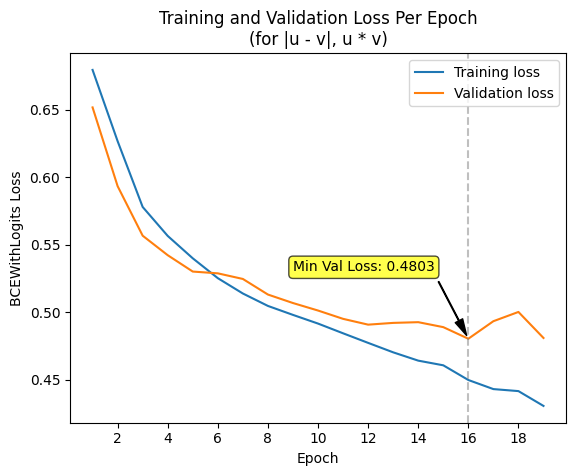

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': True, 'diff': True, 'product': False}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


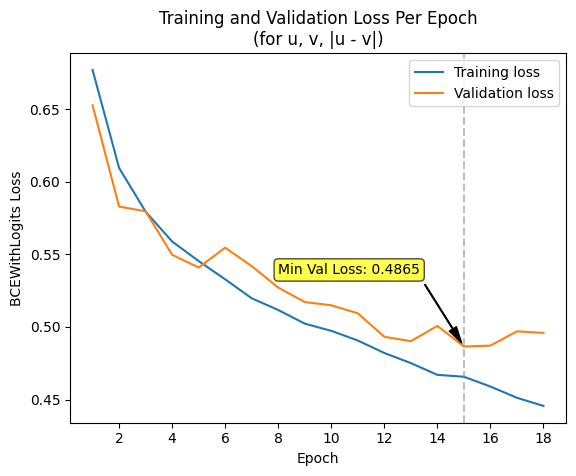

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': True, 'diff': False, 'product': False}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


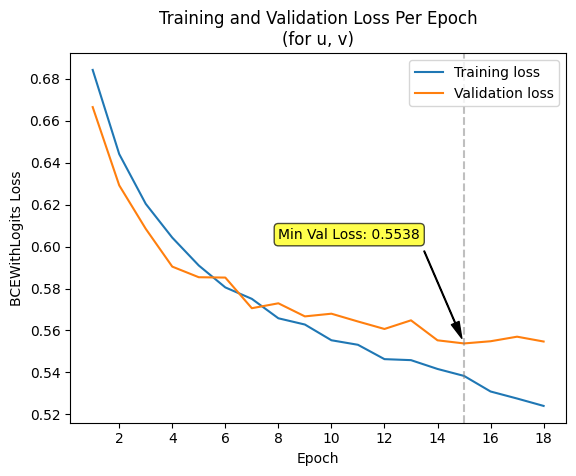

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': True, 'product': False}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


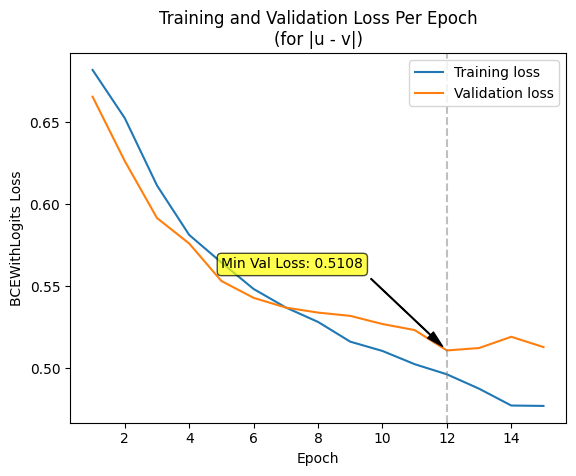

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': False, 'diff': False, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


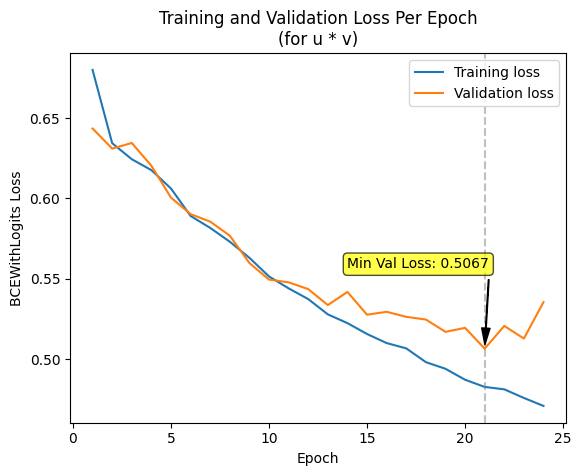

{'lstm_hidden_dim': 256, 'semantic_output_dim': 64, 'feature_config': {'u_v': True, 'diff': True, 'product': True}, 'lstm_layers': 3, 'style_output_dim': 128, 'final_output_dim': 32, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'batch_size': 128}


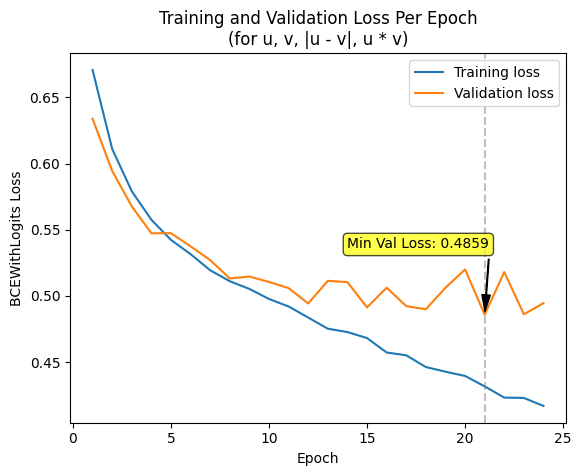

In [86]:
for i, history in enumerate(histories):
    print(history["hyperparameters"])
    x_values = np.arange(1, len(history["train_loss"]) + 1)
    y_train_loss = history["train_loss"]
    y_val_loss = history["val_loss"]
    
    min_val_loss_index = min(range(len(y_val_loss)), key=lambda i: y_val_loss[i])
    best_epoch = min_val_loss_index + 1
    best_loss = min(y_val_loss)

    plt.plot(x_values, y_train_loss, label="Training loss")
    plt.plot(x_values, y_val_loss, label="Validation loss")

    plt.locator_params(axis="x", nbins=10)
    
    plt.axvline(x=best_epoch, linestyle="--", color="grey", alpha=0.5)
    plt.annotate(
        f"Min Val Loss: {best_loss:.4f}",
        xy=(best_epoch, best_loss),
        xytext=(best_epoch - 7, best_loss + 0.05),
        arrowprops={"facecolor": "black", "shrink": 0.05, "width": 0.5, "headwidth": 6},
        bbox={"boxstyle": "round,pad=0.3", "fc": "yellow", "ec": "black", "lw": 1, "alpha": 0.7}
    )

    title = "Training and Validation Loss Per Epoch\n(for"
    if history["hyperparameters"]["feature_config"].get("u_v"):
        title += " u, v"
        if (history["hyperparameters"]["feature_config"].get("diff") or
            history["hyperparameters"]["feature_config"].get("product")):
            title += ","
    if history["hyperparameters"]["feature_config"].get("diff"):
        title += " |u - v|"
        if history["hyperparameters"]["feature_config"].get("product"):
            title += ","
    if history["hyperparameters"]["feature_config"].get("product"):
        title += " u * v"
    title += ")"
    
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("BCEWithLogits Loss")
    plt.legend(loc="upper right")
    
    plt.savefig(GRAPH_OUTPUT_PATH(i))
    plt.show()